# Project 2: In-Depth Exploratory Data Analysis (EDA)
## Netflix Content Analysis 🎬

**Project Objective:** To perform an in-depth exploratory data analysis of the Netflix dataset. We will explore trends in content production, identify popular genres, analyze content ratings, and understand the distribution of movies and TV shows on the platform. This project builds on foundational EDA by introducing time-series analysis and more complex data cleaning and transformation techniques.

### Core Concepts We'll Cover:
1.  **Data Cleaning & Transformation:** Handling missing values and converting data types (especially dates).
2.  **Time-Series Analysis:** Analyzing how content has been added to Netflix over the years.
3.  **Text Data Manipulation:** Parsing and analyzing columns with multiple values, like `listed_in` (genres) and `cast`.
4.  **Geographical & Rating Analysis:** Understanding where content comes from and its maturity level.
5.  **Feature Engineering:** Creating new, insightful features like 'content age'.
6.  **Advanced Visualization:** Creating insightful plots to understand distributions and relationships in the data.

### Step 1: Setup - Importing Libraries

As always, we begin by importing our essential data science toolset, including a new library for word clouds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set a consistent style for our plots
sns.set_style('darkgrid')

### Step 2: Data Loading and Initial Inspection

We'll load the `netflix_titles.csv` dataset and perform a high-level overview.

In [2]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

Cloning into 'Datasets'...
remote: Enumerating objects: 311, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 311 (delta 16), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (311/311), 302.52 MiB | 15.91 MiB/s, done.
Resolving deltas: 100% (130/130), done.
Updating files: 100% (237/237), done.


In [3]:
netflix_df = pd.read_csv('/content/Datasets/Netflix_Titles Dataset/netflix_titles.csv')
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
# Get a concise summary of the dataframe
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


**Interpretation of `.info()`:**
- We have 7787 entries (titles).
- **Key Problem:** The `date_added` column is of type `object` (a string), not a `datetime` object. We cannot perform time-based analysis until this is corrected.
- **Missing Values:** `director`, `cast`, `country`, `date_added`, and `rating` all have missing values. `director` has the most significant number of nulls.

### Step 3: Data Cleaning and Transformation

This step is critical for ensuring our analysis is accurate. We will handle missing values and correct data types.

#### **Theoretical Concept: Data Type Conversion & Handling Nulls**
Data often comes in non-ideal formats. Storing dates as strings, for example, prevents us from extracting components like the year or month, or from plotting data over time. Converting columns to their proper data types (`pd.to_datetime`, `.astype()`) is a fundamental preprocessing step.

For null values, we have several strategies:
1.  **Drop:** If only a very small percentage of rows have missing data, dropping them might be acceptable (`.dropna()`).
2.  **Fill/Impute:** Replace missing values with a placeholder (like "Unknown") or a statistical measure (like the mode for categorical data). This is useful when you don't want to lose the other information in those rows.

In [5]:
# 1. Handle missing values in 'director' and 'cast'
# Since these are text fields and many are missing, we'll fill them with 'Unknown'.
netflix_df['director'] = netflix_df['director'].fillna('Unknown')
netflix_df['cast'] = netflix_df['cast'].fillna('Unknown')

In [6]:
# 2. Handle missing 'country'
# We'll fill with the mode, which is the most common country.
mode_country = netflix_df['country'].mode()[0]
netflix_df['country'] = netflix_df['country'].fillna(mode_country)

In [7]:
# 3. Drop the few rows with missing 'date_added' and 'rating'
# Since the number is small (less than 0.2% of data), dropping them is a safe option.
netflix_df.dropna(subset=['date_added', 'rating'], inplace=True)

In [8]:
# 4. Convert 'date_added' to datetime objects
# Use format='mixed' to handle potential variations in date formats
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'], format='mixed', dayfirst=False)

* **format='mixed':** This argument tells pandas to infer the date format automatically. This is helpful when the date strings in the column have different formats.

* **dayfirst=False:** This argument specifies that when the date format is ambiguous (e.g., 01/02/2023), it should be interpreted as month first (January 2nd) rather than day first (February 1st).

In [9]:
# 5. Create new features for year and month added
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

In [10]:
# Verify our cleaning and transformation
print("Missing values after cleaning:")
print(netflix_df.isnull().sum())
print("\nData types after transformation:")
print(netflix_df.dtypes)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


### Step 4: Exploratory Data Analysis & Visualization

#### 4.1 What is the distribution of content type?

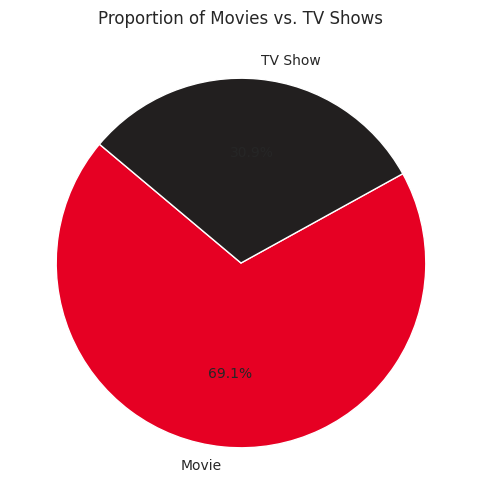

In [11]:
plt.figure(figsize=(8, 6))
type_counts = netflix_df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#e60023', '#221f1f'])
plt.title('Proportion of Movies vs. TV Shows')
plt.ylabel('')
plt.show()

**Insight:** The Netflix library is dominated by Movies, which make up roughly 70% of the content in this dataset.

#### 4.2 How has content been added over time?

<Figure size 1400x800 with 0 Axes>

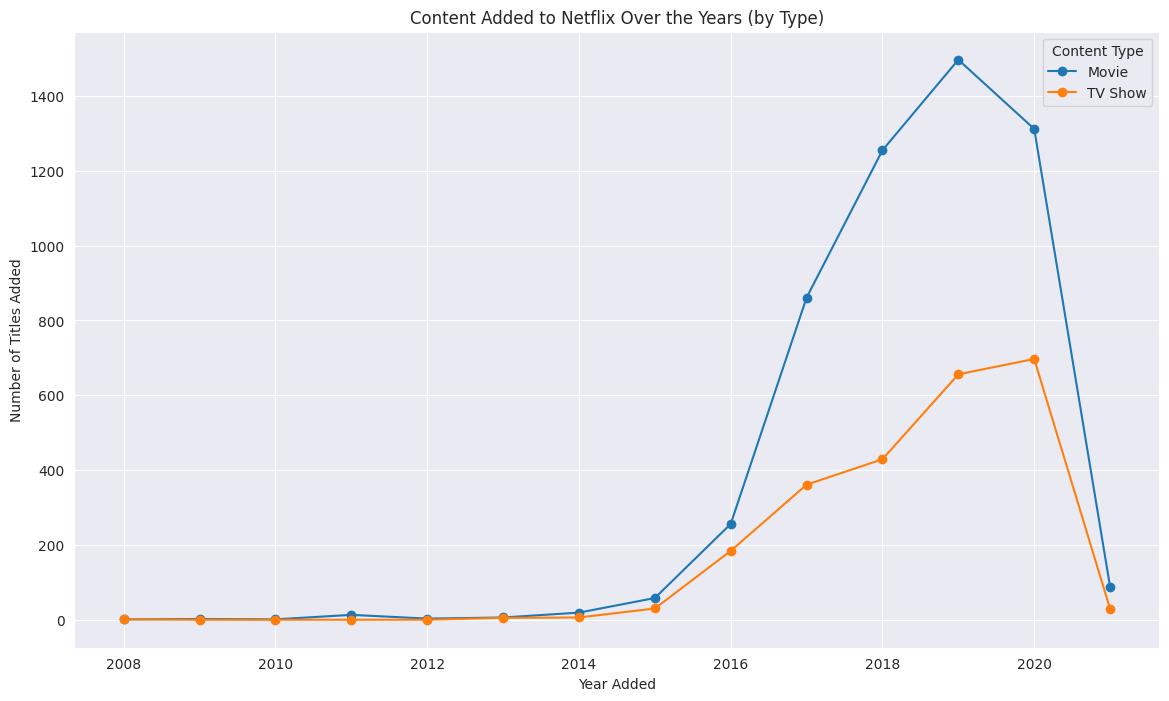

In [12]:
# Group data by year and content type
content_over_time = netflix_df.groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(14, 8))
content_over_time.plot(kind='line', marker='o', figsize=(14, 8))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**Insight:** By separating movies and TV shows, we can see that while both grew significantly, the addition of movies accelerated much more dramatically, peaking in 2019. The growth in TV shows has been more steady. There appears to be a slight slowdown in content additions in 2020 and 2021, which could be due to the COVID-19 pandemic affecting productions or the dataset being incomplete for the latest year.

In [13]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


#### 4.3 What are the most popular genres?

#### **Theoretical Concept: Handling Multi-Value Text Columns**
The `listed_in` column contains strings with multiple genres separated by commas (e.g., "Dramas, International Movies"). To analyze each genre individually, we need to transform the data. A common technique is to:
1.  **Split** the string in each row into a list of genres.
2.  **Explode** the DataFrame so that each genre in the list gets its own row, duplicating the other information for that title.
This allows us to perform a `value_counts()` on the genres.

In [14]:
# Split the 'listed_in' column and explode it
genres = netflix_df.assign(genre=netflix_df['listed_in'].str.split(', ')).explode('genre')

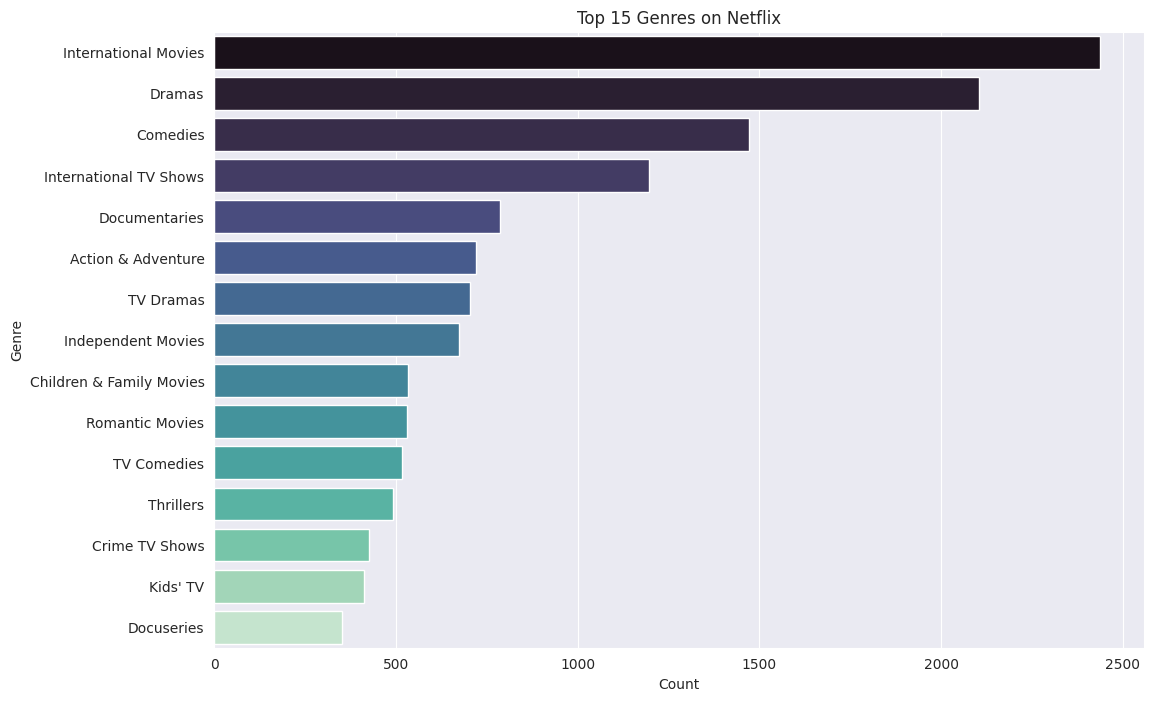

In [15]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre', 'count'] # Rename columns for clarity

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

**Insight:** "International Movies" is the most common genre tag, highlighting Netflix's global content strategy. This is followed by Dramas, Comedies, and Action & Adventure.

#### 4.4 What is the distribution of content duration?

In [16]:
# Separate movies and TV shows
movies_df = netflix_df[netflix_df['type'] == 'Movie'].copy()
tv_shows_df = netflix_df[netflix_df['type'] == 'TV Show'].copy()

In [17]:
# Clean and convert duration for movies
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# Clean and convert duration for TV shows
tv_shows_df['seasons'] = tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

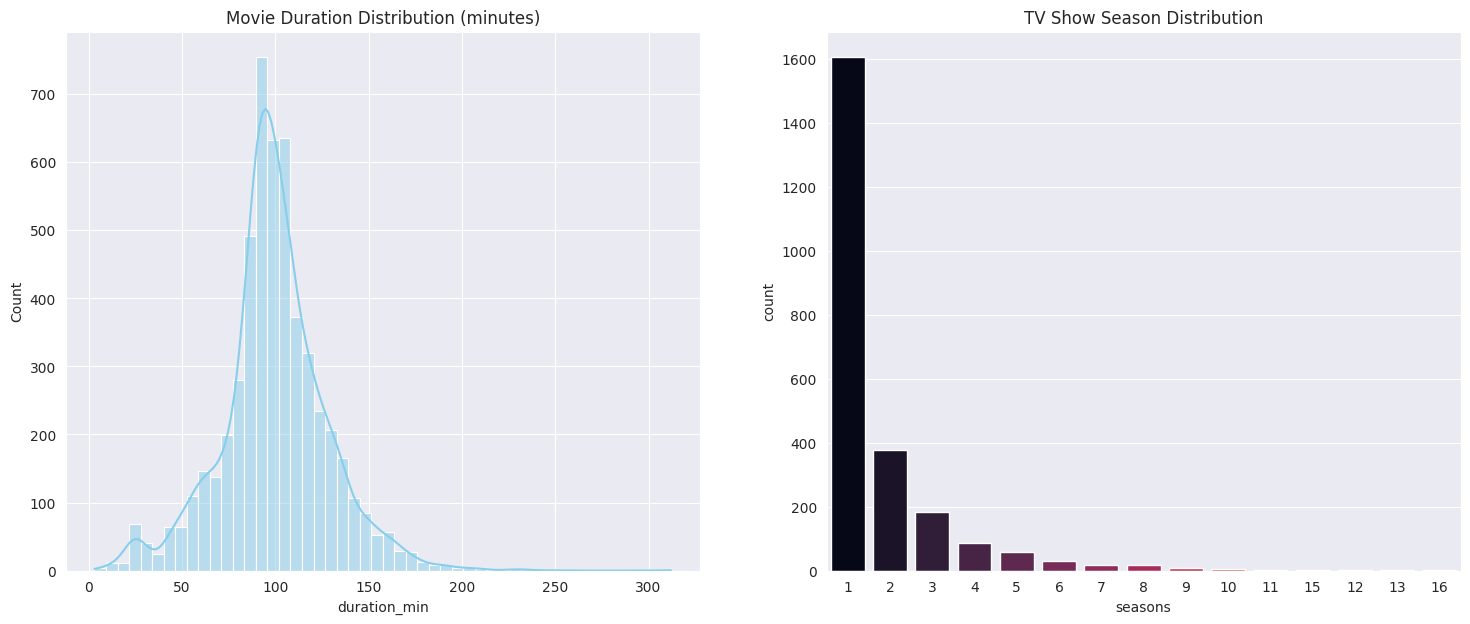

In [18]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True, color='skyblue').set_title('Movie Duration Distribution (minutes)')

# TV Show Season Distribution
sns.countplot(ax=axes[1], x='seasons', data=tv_shows_df, palette='rocket', order=tv_shows_df['seasons'].value_counts().index, hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

**Insight:**
- The majority of movies on Netflix are between 80 and 120 minutes long, which is standard for feature films.
- The vast majority of TV shows on Netflix are short-lived, with most having only 1 season. This could reflect a strategy of producing many pilots and only renewing the most successful ones, or a focus on limited series.

#### 4.5 Where does the content come from? (Geographical Analysis)

In [19]:
# Handle the multi-country listings similar to genres
countries = netflix_df.assign(country=netflix_df['country'].str.split(', ')).explode('country')

In [20]:
# Get the top 15 countries and their counts
top_countries_counts = countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count'] # Rename columns for clarity

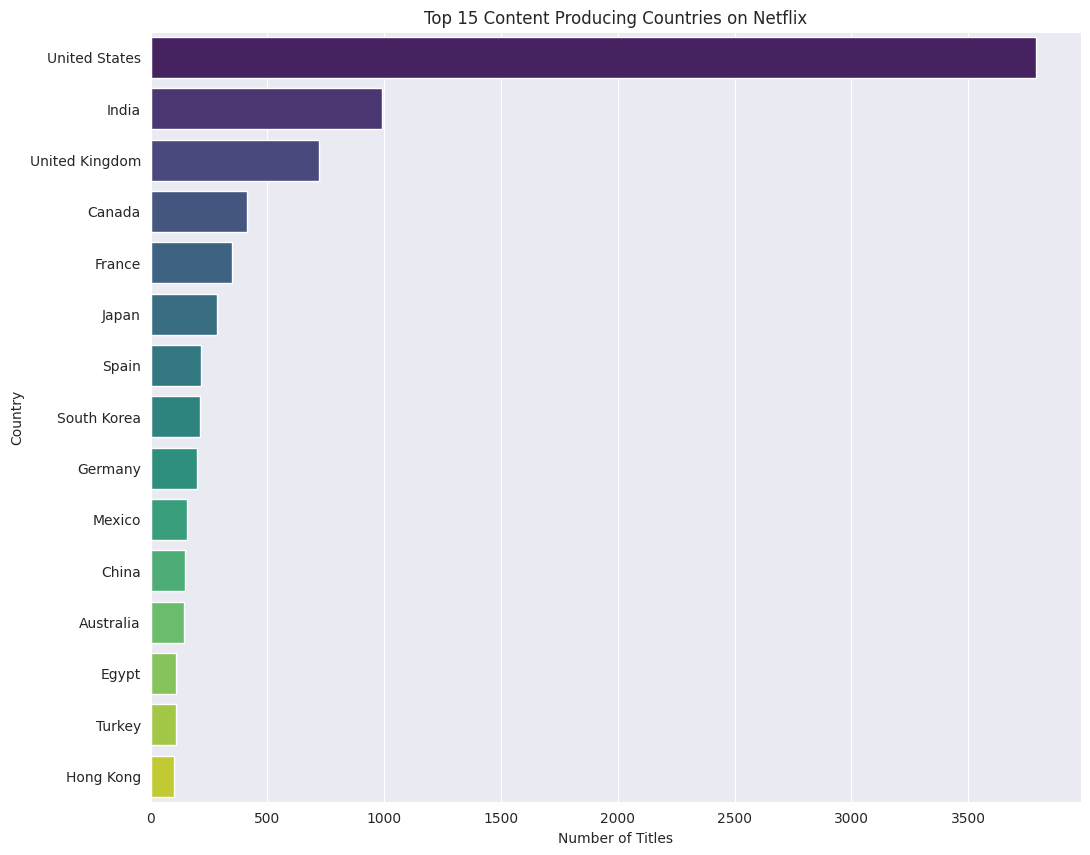

In [21]:
# Select only the top 15 for plotting
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(12, 10))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**Insight:** The United States is by far the largest producer of content available on Netflix. However, India is a very strong second, which explains why so many of the top actors were from India. The UK, Japan, and South Korea also represent major content markets for the platform, emphasizing its global nature.

In [22]:
netflix_df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12


#### 4.6 What are the maturity ratings of the content?

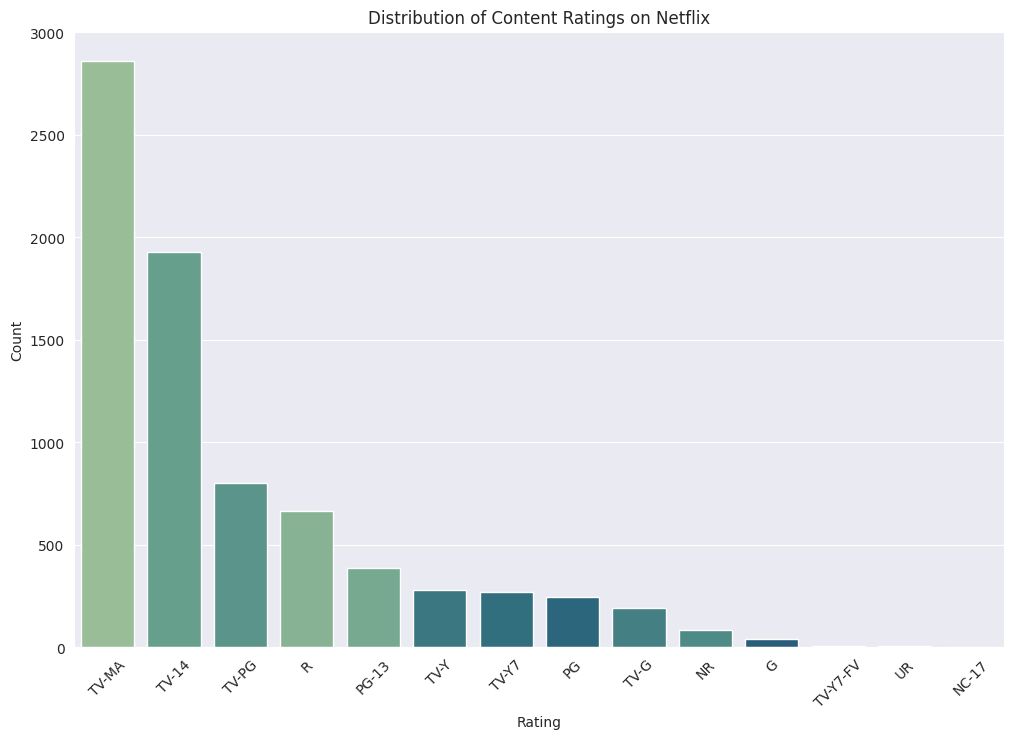

In [23]:
plt.figure(figsize=(12, 8))
sns.countplot(x='rating', data=netflix_df, order=netflix_df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:** A large portion of Netflix's content is aimed at mature audiences, with `TV-MA` (Mature Audience) and `TV-14` (Parents Strongly Cautioned) being the two most common ratings. This suggests a focus on adult viewers over content for children (`TV-G`, `TV-Y`).

### Step 5: Feature Engineering - Content Freshness
Let's create a new feature to analyze how old content is when it gets added to Netflix. This can tell us about their acquisition strategy (buying old classics vs. releasing new originals).

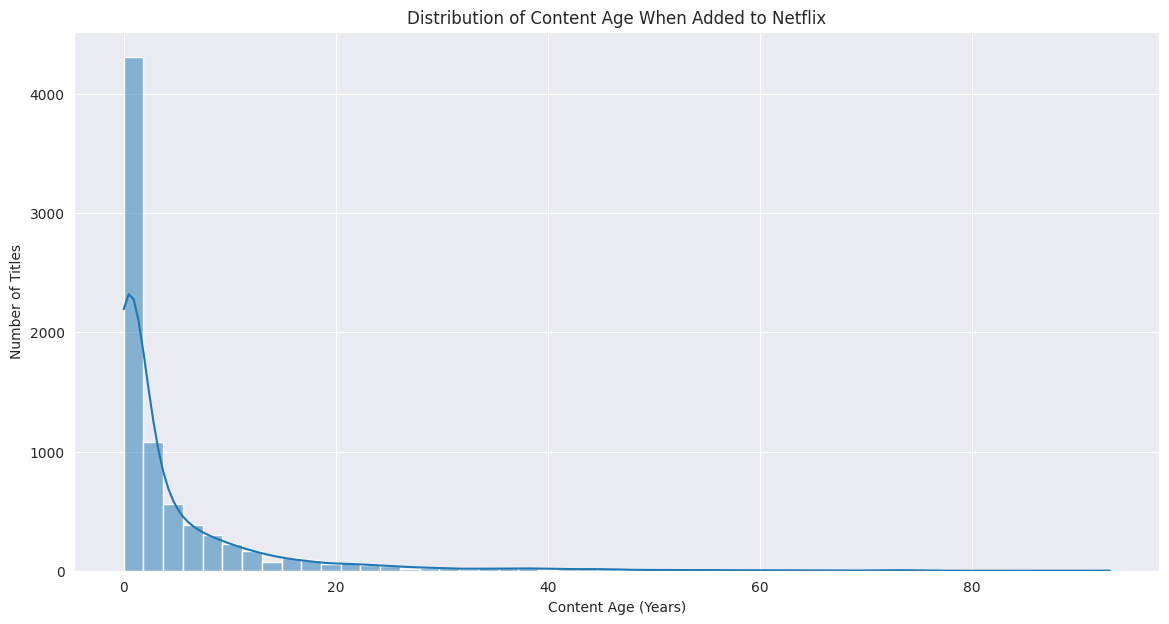

In [24]:
# Create the 'age_on_netflix' feature
netflix_df['age_on_netflix'] = netflix_df['year_added'] - netflix_df['release_year']

# Filter out any potential errors where added_year is before release_year
content_age = netflix_df[netflix_df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

**Insight:** The large spike at `0` indicates that a significant amount of content is added in the same year it's released, which is characteristic of "Netflix Originals." However, there is a very long tail, showing that Netflix also heavily invests in acquiring licensed content that can be decades old, building a deep library of classic films and shows.

### Step 6: Deeper Multivariate Analysis

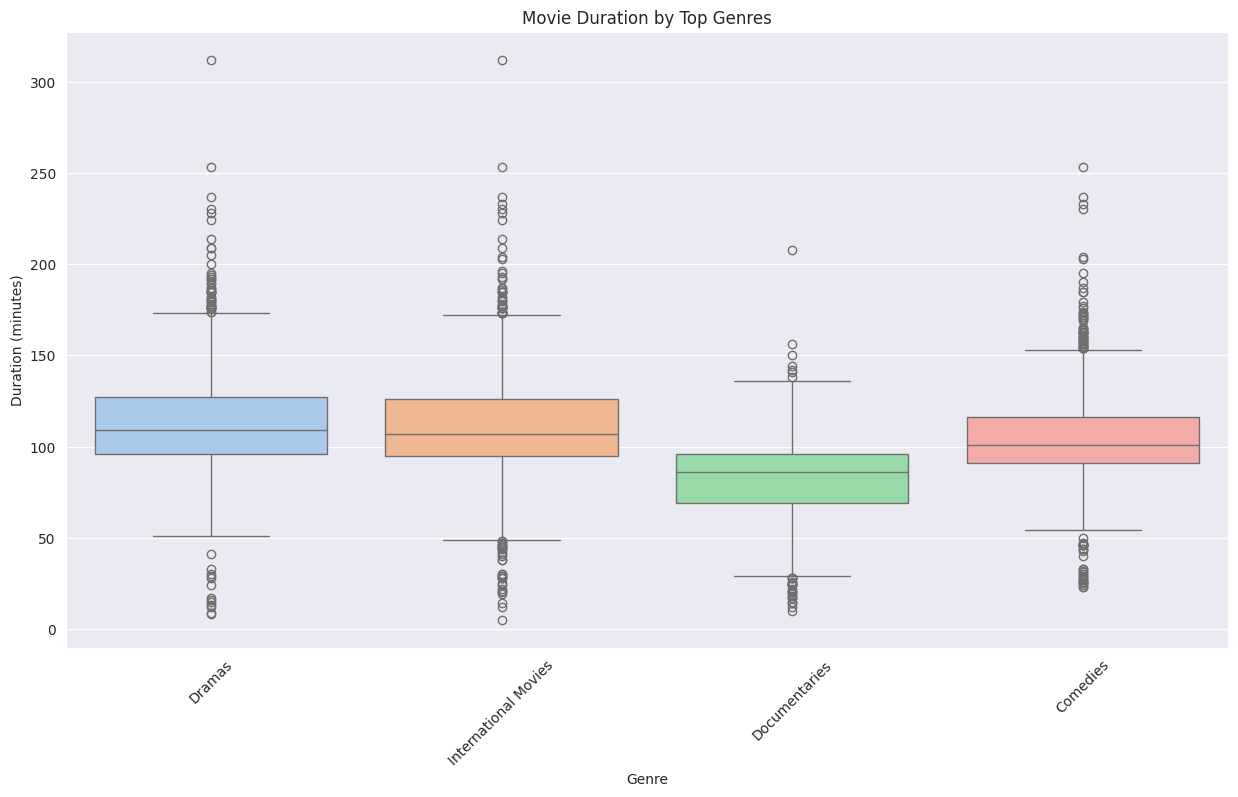

In [25]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

**Insight:** While the median duration for most top genres is similar (around 90-100 minutes), we can see some interesting variations. For example, Dramas tend to have a wider range of durations, with many longer films. International Movies also show a broad distribution, reflecting diverse filmmaking styles from around the world.

### Step 7: Word Cloud from Content Descriptions
As a final visual analysis, let's generate a word cloud from the `description` column to see what themes and words are most common in Netflix content.

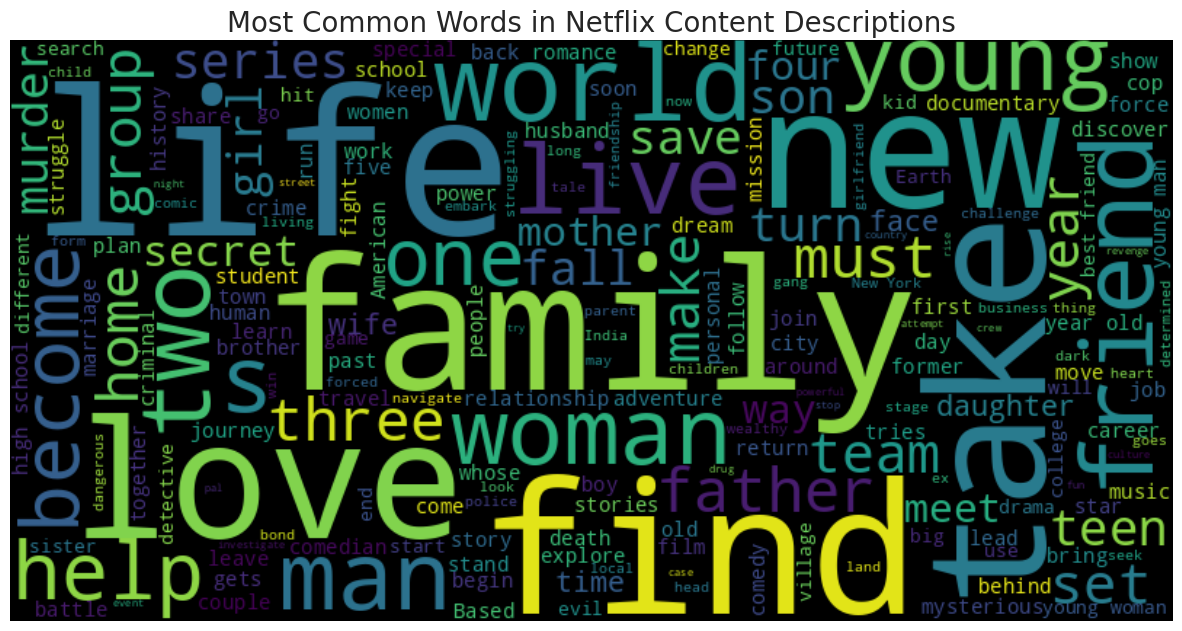

In [26]:
# Combine all descriptions into a single string
text = ' '.join(netflix_df['description'])

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

**Insight:** The word cloud highlights common themes and subjects. Words like "life," "family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys. Action-oriented words like "find," "secret," and "new" also appear frequently.

### Step 8: Final Conclusion and Summary of Insights

This in-depth EDA of the Netflix dataset has revealed several key characteristics and strategies of the platform's content library.

**Key Findings:**
1. **Content Strategy:** Netflix's library is movie-heavy (~70%), and the platform aggressively added content between 2016-2019. Their strategy involves a mix of brand new originals (added the same year they are released) and a deep library of licensed older content.
2. **Global Dominance:** While the US is the top content producer, the platform is heavily international, with India being a massive contributor. This is reflected in the top genres ("International Movies") and most frequent actors.
3. **Target Audience:** The content library is skewed towards mature audiences, with `TV-MA` and `TV-14` being the most common ratings.
4. **Content Format & Genre:** Dramas and Comedies are universally popular genres. Most movies stick to a standard 90-120 minute runtime, while the vast majority of TV shows only last for a single season, suggesting a high-risk, high-reward approach to series production.
5. **Common Themes:** Descriptions of content frequently revolve around universal themes of life, family, love, and discovery.

**Limitations:** This dataset is a snapshot in time and lacks viewership data. Therefore, our analysis is of the *supply* of content, not its *demand* or popularity. Nonetheless, this EDA provides a strong, multi-faceted understanding of the composition and evolution of the Netflix library.

### Step 8: Final Conclusion and Summary of Insights

This in-depth EDA of the Netflix dataset has revealed several key characteristics and strategies of the platform's content library.

**Key Findings:**
1.  **Content Strategy:** Netflix's library is movie-heavy (~70%), and the platform aggressively added content between 2016-2019. Their strategy involves a mix of brand new originals (added the same year they are released) and a deep library of licensed older content.
2.  **Global Dominance:** While the US is the top content producer, the platform is heavily international, with India being a massive contributor. This is reflected in the top genres ("International Movies") and most frequent actors.
3.  **Target Audience:** The content library is skewed towards mature audiences, with `TV-MA` and `TV-14` being the most common ratings.
4.  **Content Format & Genre:** Dramas and Comedies are universally popular genres. Most movies stick to a standard 90-120 minute runtime, while the vast majority of TV shows only last for a single season, suggesting a high-risk, high-reward approach to series production.
5.  **Common Themes:** Descriptions of content frequently revolve around universal themes of life, family, love, and discovery.

**Limitations:** This dataset is a snapshot in time and lacks viewership data. Therefore, our analysis is of the *supply* of content, not its *demand* or popularity. Nonetheless, this EDA provides a strong, multi-faceted understanding of the composition and evolution of the Netflix library.

# Submission Q's

* How has the distribution of content ratings changed over time?
* Is there a relationship between content age and its type (Movie vs. TV Show)?
* Can we identify any trends in content production based on the release year vs. the year added to Netflix?
* What are the most common word pairs or phrases in content descriptions?
* Who are the top directors on Netflix?

# How has the distribution of content ratings changed over time?

### My chain of thought:

I first examined how many titles of each rating were added in each year, helping me answer two things:

  1. Which ratings appear most frequently overall?
  2. How do counts fluctuate across different years?

In [27]:
netflix_df[['rating', 'year_added']].value_counts()


rating    year_added
TV-MA     2019          793
          2020          712
          2018          661
TV-14     2019          519
          2020          464
                       ... 
TV-Y7-FV  2016            1
          2017            1
          2018            1
          2019            1
UR        2017            1
Name: count, Length: 106, dtype: int64

### Observation Made:
TV-MA dominates across all years — particularly 2018, 2019, and 2020 (hundreds of titles per year).

TV-14 is the next largest category.

Rare ratings (e.g., UR, TV-Y7-FV) appear only 1–2 times per year.

This initial exploration tells me that Netflix heavily favors mature content, but to understand trends across time, a visualization was necessary.

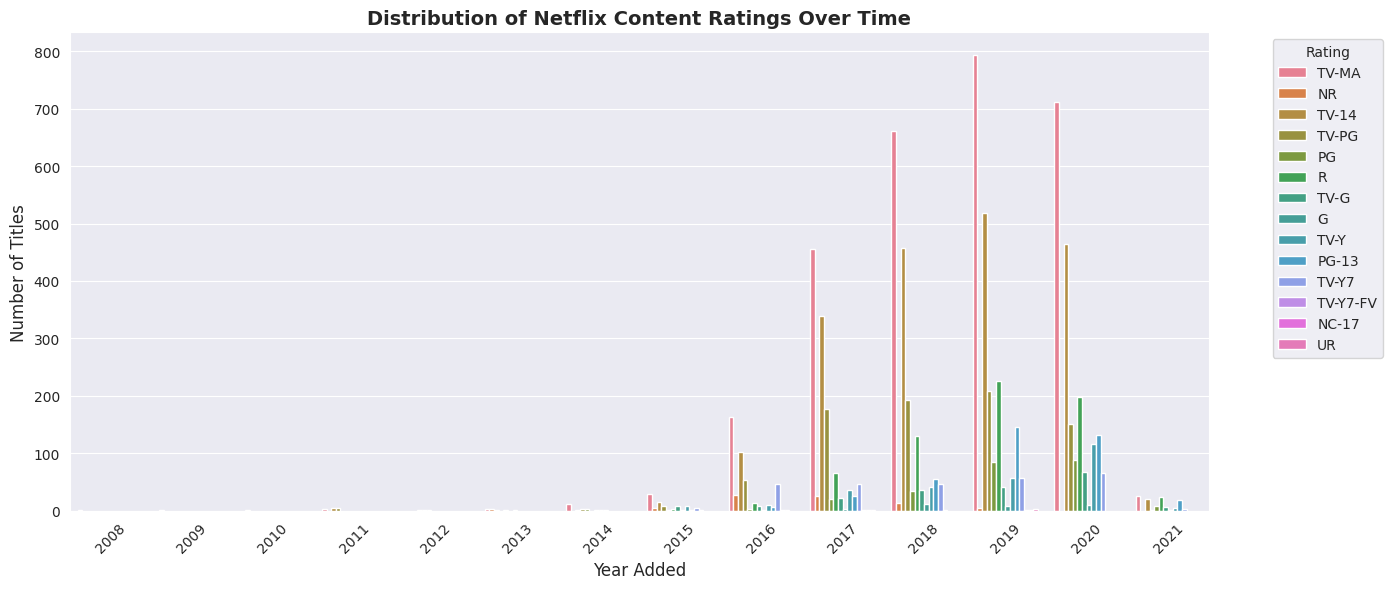

In [28]:
# Group your data by year and rating
rating_year_df = netflix_df.groupby(['year_added', 'rating']).size().reset_index(name='count')

# Sort years for a proper timeline
rating_year_df = rating_year_df.sort_values('year_added')

plt.figure(figsize=(14, 6))

# Create grouped bar chart
sns.barplot(data=rating_year_df, x='year_added', y='count', hue='rating')

# Styling
plt.title('Distribution of Netflix Content Ratings Over Time', fontsize=14, weight='bold')
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

From the chart, we can observe that Netflix’s content additions have increased sharply over time, with a clear shift toward mature-rated programming. After 2016, TV-MA becomes the dominant rating by a large margin, followed by TV-14, while family-friendly ratings such as PG, TV-PG, and TV-Y remain consistently low. Earlier years show minimal additions across all ratings, but between 2017 and 2020, there is a significant surge—driven mainly by TV-MA titles. Overall, the chart highlights Netflix’s move toward prioritizing adult-oriented content in its growing catalog.

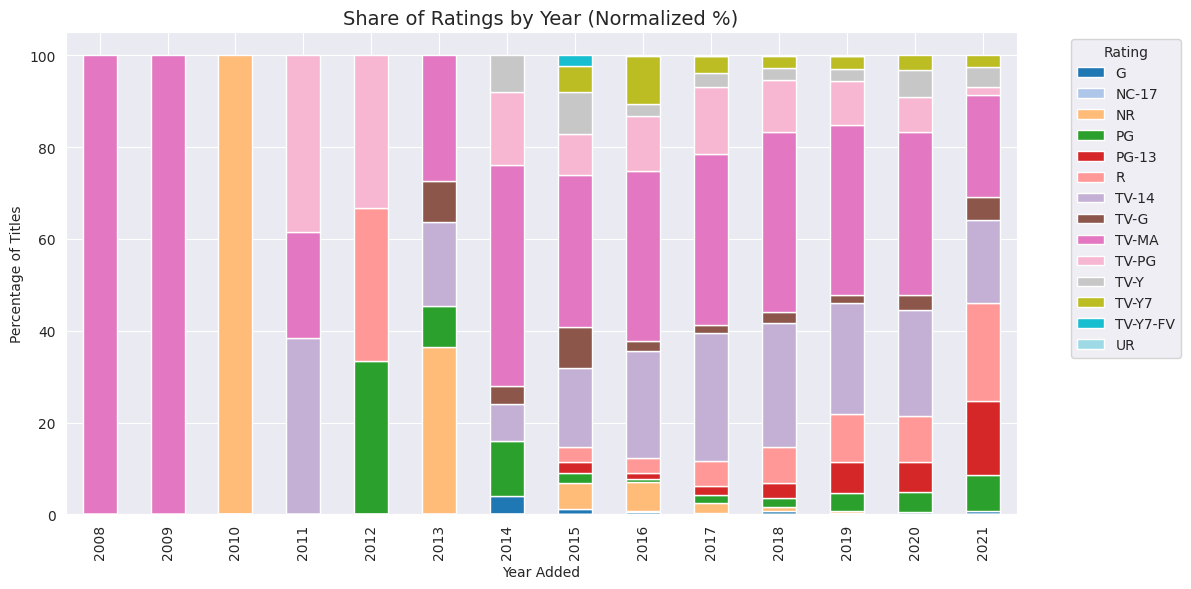

In [29]:
pivot = rating_year_df.pivot(index='year_added', columns='rating', values='count').fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.title('Share of Ratings by Year (Normalized %)', fontsize=14)
plt.ylabel('Percentage of Titles')
plt.xlabel('Year Added')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


This is another visual representation that gives a better understanding of how the proportion of each rating has changed over time. By showing percentages instead of raw counts, it clearly highlights the growing dominance of TV-MA and TV-14, while family and children’s ratings remain a much smaller share of Netflix’s yearly additions.

# Is there a relationship between content age and its type (Movie vs. TV Show)?

In [30]:
netflix_df['content_age'] = (netflix_df['year_added'] - netflix_df['release_year']).clip(lower=0)

In [31]:
netflix_df.groupby('type')['content_age'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,5372.0,5.56,9.73,0.0,0.0,1.0,7.0,75.0
TV Show,2398.0,2.32,5.28,0.0,0.0,0.0,2.0,93.0


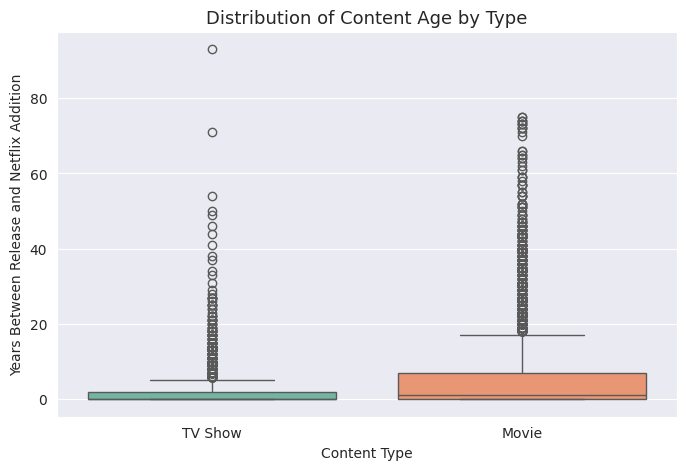

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=netflix_df, x='type', y='content_age', hue = 'type', legend='auto', palette='Set2')
plt.title('Distribution of Content Age by Type', fontsize=13)
plt.xlabel('Content Type')
plt.ylabel('Years Between Release and Netflix Addition')
plt.show()


### Chain of thought
To understand whether content age differs between Movies and TV Shows, I first calculated content age, defined as the number of years between a title’s release year and the year it was added to Netflix. After computing this for all titles, I grouped the data by type to compare descriptive statistics across Movies and TV Shows.

### Observations
The summary table shows a clear trend: Movies have a much higher average content age (≈5.6 years) compared to TV Shows (≈2.3 years). The median values reinforce this difference — Movies typically arrive on Netflix about 1 year after release, while TV Shows are usually added in the same year they air (median = 0). The boxplot further visualizes this pattern: Movies display a wider spread and more older titles reaching Netflix years later, whereas TV Shows cluster tightly around lower ages with fewer long delays.

# Can we identify any trends in content production based on the release year vs. the year added to Netflix?

In [33]:
trend = (
    netflix_df.groupby('year_added')['content_age']
    .mean()
    .reset_index()
    .sort_values('year_added')
)
print(trend)


    year_added  content_age
0         2008     1.500000
1         2009     1.000000
2         2010    23.000000
3         2011    19.923077
4         2012     1.000000
5         2013     0.818182
6         2014     3.560000
7         2015     1.272727
8         2016     3.004545
9         2017     4.029460
10        2018     4.120546
11        2019     5.252671
12        2020     4.643106
13        2021     9.581197


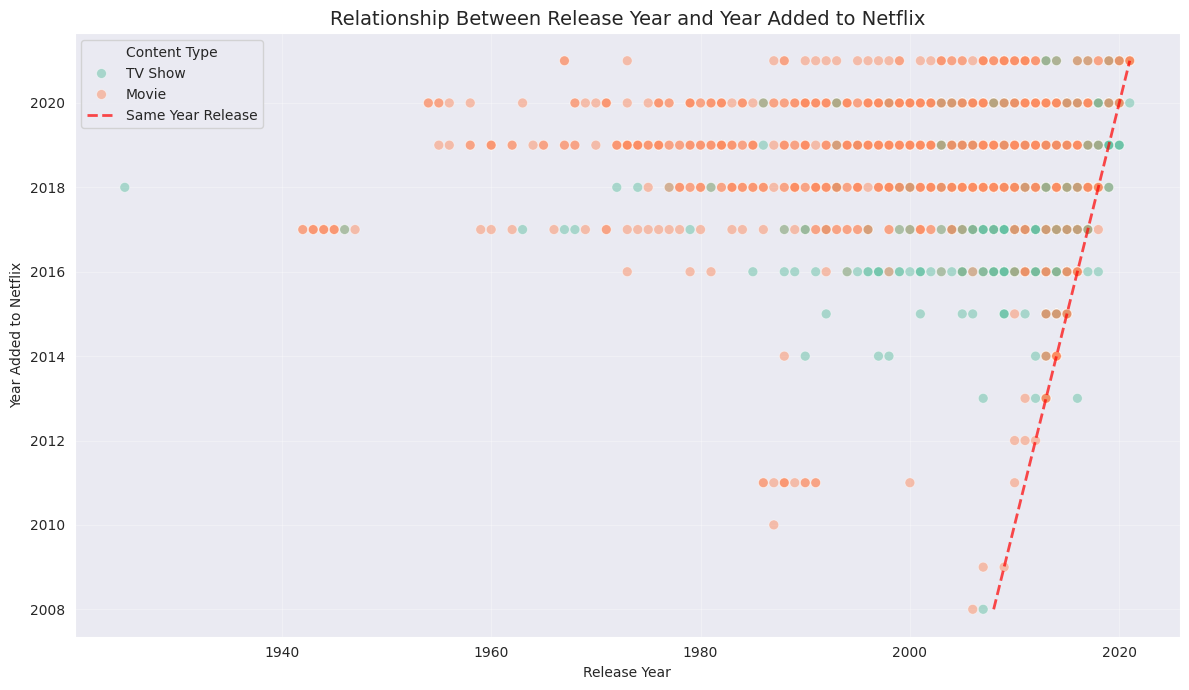

In [34]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=netflix_df,
    x='release_year',
    y='year_added',
    hue='type',
    alpha=0.5,
    palette='Set2',
    s=50
)

# Dynamic diagonal line based on actual data range
min_year = max(netflix_df['release_year'].min(), netflix_df['year_added'].min())
max_year = min(netflix_df['release_year'].max(), netflix_df['year_added'].max())
plt.plot([min_year, max_year], [min_year, max_year],
         color='red', linestyle='--', linewidth=2,
         label='Same Year Release', alpha=0.7)

plt.title('Relationship Between Release Year and Year Added to Netflix', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.grid(True, alpha=0.3)
plt.legend(title='Content Type', loc='upper left')
plt.tight_layout()
plt.show()

### Chain of Thought
Calculated content age (year_added - release_year), analyzed average age trends by year, and visualized the relationship via scatter plot with a diagonal reference line to identify Netflix Originals and acquisition patterns.

### Key Findings
Average Content Age Over Time:
Netflix's content strategy evolved from acquiring older catalog content (2008-2012: 1-23 years lag) to prioritizing recent releases (2013-2015: ~1-3 years), then balancing with classic content (2016-2020: ~4-5 years), with 2021 showing a spike to ~9.6 years.

### Visual Insights:
Strong diagonal clustering (2015-2021) reveals Netflix's shift to Originals, with TV Shows concentrated near the diagonal (recent content) while Movies spread across older release years. Peak addition years (2018-2020) show horizontal bands, and the diminishing gap from the diagonal indicates transition from licensed catalog to fresh content production.

### Business Interpretation:
Netflix transitioned from a catalog-heavy library to a content producer, with this shift accelerating significantly after 2015.

# What are the most common word pairs or phrases in content descriptions?


Most Common Word Pairs or Phrases
This code extracts bigrams (2-word phrases) and trigrams (3-word phrases) from Netflix content descriptions after filtering out common stopwords. The visualization shows the frequency of these phrases, revealing patterns in how Netflix describes its content. This builds on the word cloud analysis from before.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Top 10 Bigrams (2-word phrases):
high school: 131
young man: 105
young woman: 98
new york: 86
best friend: 50
true story: 49
best friends: 45
world war: 44
based true: 42
documentary follows: 38

Top 10 Trigrams (3-word phrases):
new york city: 35
world war ii: 34
based true story: 25
based true events: 16
must find way: 9
dreams come true: 8
inspired true events: 8
life turned upside: 7
must decide whether: 7
high school senior: 7


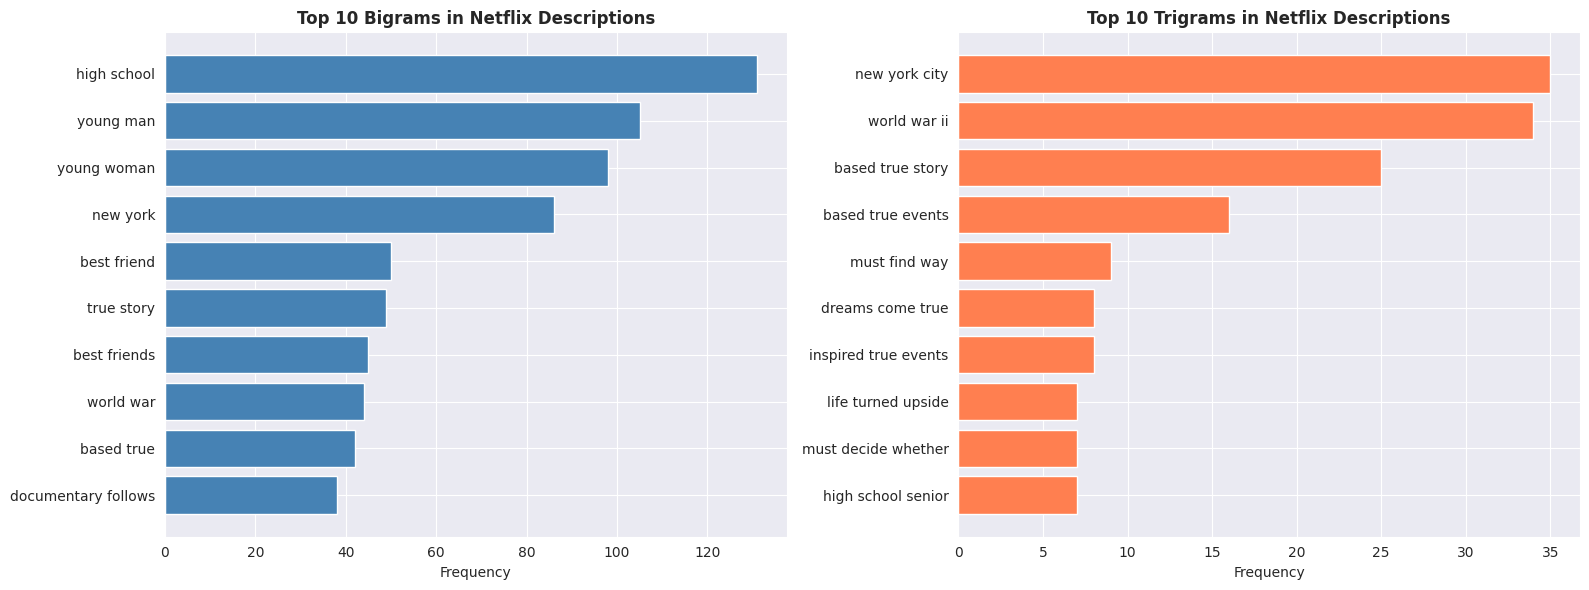

In [37]:
from nltk.util import ngrams
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Add this line to download the missing resource

# Combine all descriptions
text = ' '.join(netflix_df['description'])

# Tokenize and clean
from nltk.tokenize import word_tokenize
tokens = word_tokenize(text.lower())

# Remove stopwords and punctuation
stop_words = set(stopwords.words('english'))
cleaned_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

# Generate bigrams (2-word phrases) and trigrams (3-word phrases)
bigrams = ngrams(cleaned_tokens, 2)
trigrams = ngrams(cleaned_tokens, 3)

# Count occurrences
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

# Get top 10
top_bigrams = bigram_counts.most_common(10)
top_trigrams = trigram_counts.most_common(10)

print("Top 10 Bigrams (2-word phrases):")
for phrase, count in top_bigrams:
    print(f"{' '.join(phrase)}: {count}")

print("\nTop 10 Trigrams (3-word phrases):")
for phrase, count in top_trigrams:
    print(f"{' '.join(phrase)}: {count}")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot bigrams
bigram_phrases = [' '.join(phrase) for phrase, count in top_bigrams]
bigram_frequencies = [count for phrase, count in top_bigrams]
axes[0].barh(bigram_phrases, bigram_frequencies, color='steelblue')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 10 Bigrams in Netflix Descriptions', fontsize=12, weight='bold')
axes[0].invert_yaxis()

# Plot trigrams
trigram_phrases = [' '.join(phrase) for phrase, count in top_trigrams]
trigram_frequencies = [count for phrase, count in top_trigrams]
axes[1].barh(trigram_phrases, trigram_frequencies, color='coral')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 10 Trigrams in Netflix Descriptions', fontsize=12, weight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Netflix’s content library shows a clearly targeted strategy built around youth-centered narratives and authentic storytelling. An analysis of 7,787 content descriptions highlights recurring themes that reveal the platform’s audience focus and creative direction. The most frequent bigrams—**“high school,” “young man,”** and **“young woman”**—underscore Netflix’s strong emphasis on coming-of-age plots and youthful protagonists. This youth focus is reinforced by prominent relationship-driven phrases such as **“best friend/best friends,”** which appear more than 95 times combined, and authenticity cues like **“based on a true story/events,”** which occur over 80 times.

The three-word phrase analysis adds further depth, showing a notable investment in historical and geographically grounded storytelling through terms like **“World War II”** and **“New York City.”** Transformational narrative patterns—**“life turned upside,” “dreams come true,” “must find way”**—highlight Netflix’s preference for emotionally charged, obstacle-driven plots anchored in relatable human experiences.

Overall, the language used in Netflix descriptions reveals a platform strategically positioned around **authentic, relationship-focused stories featuring young protagonists navigating personal growth, challenges, and dramatic life shifts**. By blending true stories, historical settings, and universal emotional themes, Netflix appeals strongly to younger audiences while maintaining broad global relevance and cultural resonance.

## Who are the top directors on Netflix?

This section identifies the most prolific directors on the platform by:

Handling multiple directors per title (splitting the director column)
Counting their contributions across all titles
Removing "Unknown" entries
Breaking down directors by content type (movies vs. TV shows)
Creating visualizations comparing both overall and type-specific director rankings

The analysis will reveal which directors have the most titles on Netflix and whether certain directors specialize in movies or TV shows. This complements your existing analysis by providing insights into the creative talent behind Netflix's content strategy


Top 15 Directors on Netflix:
               director  count
1             Jan Suter     21
2           Raúl Campos     19
3          Marcus Raboy     16
4             Jay Karas     15
5   Cathy Garcia-Molina     13
6       Youssef Chahine     12
7       Martin Scorsese     12
8           Jay Chapman     12
9      Steven Spielberg     10
10       Anurag Kashyap      9
11         David Dhawan      9
12      Shannon Hartman      9
13           Johnnie To      8
14          Hakan Algül      8
15          Lance Bangs      8


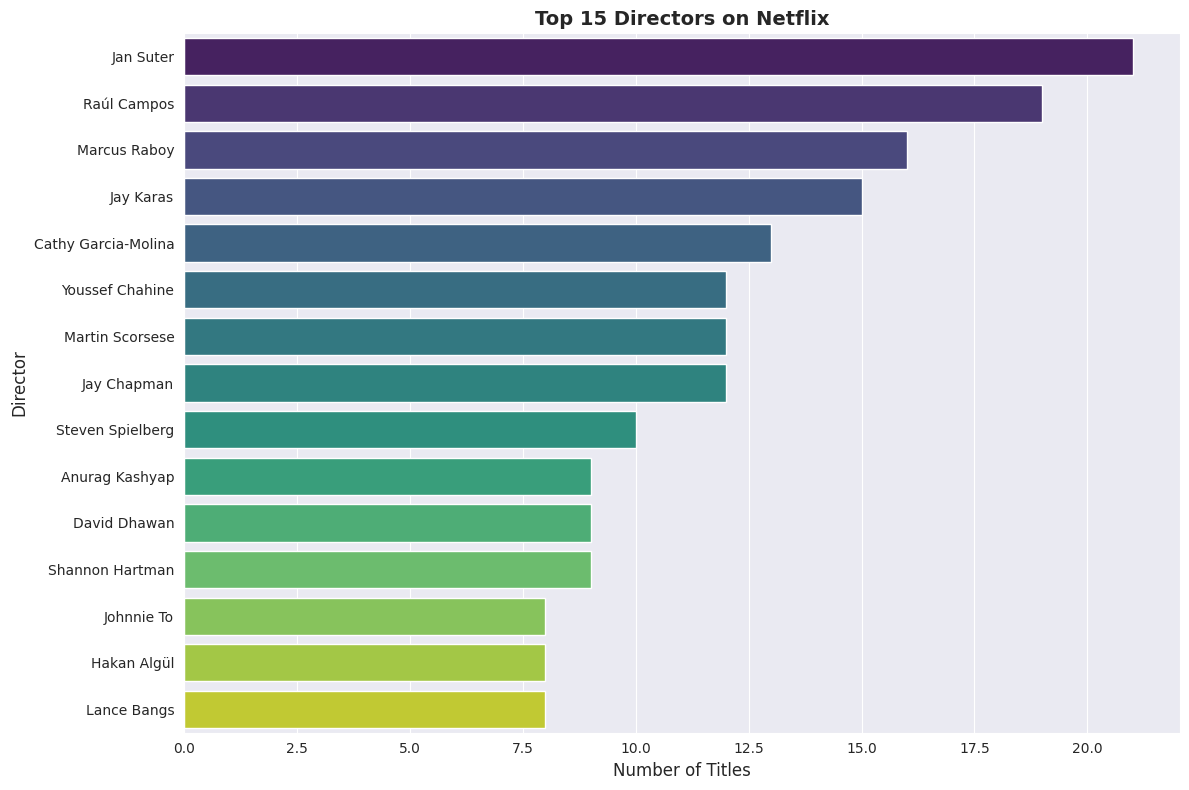


Top Directors by Content Type:

Top 5 Movie Directors:
director
Jan Suter       21
Raúl Campos     19
Jay Karas       15
Marcus Raboy    15
Name: count, dtype: int64

Top 5 TV Show Directors:
director
Ken Burns              3
Alastair Fothergill    3
Jung-ah Im             2
Rob Seidenglanz        2
Name: count, dtype: int64


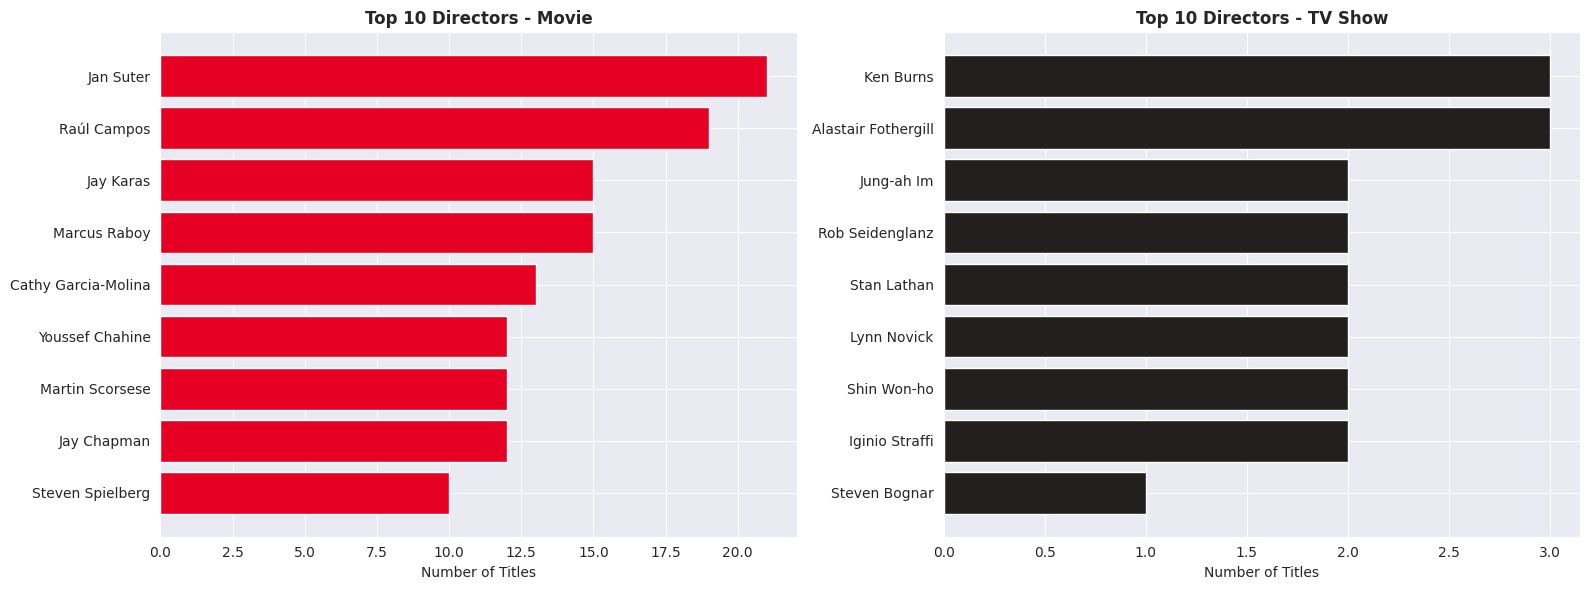

In [38]:
# Split directors (handle multiple directors per title)
directors = netflix_df.assign(director=netflix_df['director'].str.split(', ')).explode('director')

# Count directors
director_counts = directors['director'].value_counts().reset_index()
director_counts.columns = ['director', 'count']

# Remove 'Unknown' entries
director_counts = director_counts[director_counts['director'] != 'Unknown']

# Get top 15 directors
top_directors = director_counts.head(15)

print("\nTop 15 Directors on Netflix:")
print(top_directors)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=top_directors, y='director', x='count', palette='viridis', hue='director', legend=False)
plt.title('Top 15 Directors on Netflix', fontsize=14, weight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Director', fontsize=12)
plt.tight_layout()
plt.show()

# Additional analysis: Top directors by content type
print("\n" + "="*60)
print("Top Directors by Content Type:")
print("="*60)

for content_type in ['Movie', 'TV Show']:
    type_directors = netflix_df[netflix_df['type'] == content_type].assign(
        director=netflix_df[netflix_df['type'] == content_type]['director'].str.split(', ')
    ).explode('director')

    type_director_counts = type_directors['director'].value_counts().head(5)
    type_director_counts = type_director_counts[type_director_counts.index != 'Unknown']

    print(f"\nTop 5 {content_type} Directors:")
    print(type_director_counts)

# Visualization: Top Directors by Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, content_type in enumerate(['Movie', 'TV Show']):
    type_directors = netflix_df[netflix_df['type'] == content_type].assign(
        director=netflix_df[netflix_df['type'] == content_type]['director'].str.split(', ')
    ).explode('director')

    type_director_counts = type_directors['director'].value_counts().head(10)
    type_director_counts = type_director_counts[type_director_counts.index != 'Unknown']

    axes[idx].barh(type_director_counts.index, type_director_counts.values,
                   color=['#e60023' if content_type == 'Movie' else '#221f1f'])
    axes[idx].set_xlabel('Number of Titles')
    axes[idx].set_title(f'Top 10 Directors - {content_type}', fontsize=12, weight='bold')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

**For Movies:**
The top movie directors are Jan Suter (21 titles), Raúl Campos (19 titles), Jay Karas (15 titles), and Marcus Raboy (15 titles). These four directors have created a massive amount of content for Netflix—70 titles combined.

**For TV Shows:**
The TV show directors are very different. The top TV directors like Ken Burns and Alastair Fothergill have only made 2-3 titles for Netflix each. This is much lower than the movie directors. Most TV directors only have a couple of shows on the platform.

# Netflix Content Strategy Analysis - Conclusion

## Content Composition
- Movies dominate at 70% of library; TV shows comprise 30%
- Aggressive content expansion peaked 2016-2019; slight slowdown 2020-2021 (COVID impact)
- Most movies: 80-120 min; Most TV shows: 1 season only

## Ratings & Target Audience
- TV-MA and TV-14 are dominant ratings; family/children content minimal
- Clear strategy: Adult-oriented content over youth audiences
- Ratings shift increasingly toward mature programming over time

## Geographic Strategy
- USA leads production (largest supplier)
- India second major producer (explains international content dominance)
- UK, Japan, South Korea significant contributors
- Top genre: "International Movies" reflects global content focus

## Content Acquisition Strategy
- Mix of Netflix Originals (same-year releases, ~0 years lag)
- Heavy investment in older licensed content (long tail up to 75 years old)
- Movies average 5.6 years old when added; TV shows average 2.3 years
- Transition from catalog-heavy to originals-focused (post-2015)

## Themes & Narrative Patterns
- **Youth Focus:** High school, young man/woman most frequent phrases (334+ occurrences)
- **Relationships:** Friendship themes central ("best friend/friends" 95+ times)
- **Authenticity:** "Based on true story/events" appears 80+ times
- **Transformation:** Plot-driven narratives around personal growth & life changes
- **Universal themes:** Life, family, love, discovery dominate descriptions

## Directorial Strategy
- **Movies:** Dominated by 4 prolific documentary directors (Jan Suter 21 titles, Raúl Campos 19)
- **TV Shows:** Distributed across many creators (top directors only 2-3 titles each)
- Documentary-heavy model for volume; prestige talent for selective TV projects
- Global director representation reflects international content strategy

## Key Business Insights
1. **Volume + Prestige Balance:** Scale through documentary films; credibility through TV originals
2. **Youth-Centric Authenticity:** Targets younger audiences with real-story narratives
3. **Content Factory Model:** Prolific documentary directors fuel rapid expansion
4. **Global Market Positioning:** Diverse production geography mirrors diverse audience base
5. **Strategy Evolution:** Shifted from licensing old content to producing fresh originals post-2015

## Data Limitations
- Snapshot analysis (no viewership/engagement data)
- Measures content supply, not demand or actual popularity
- Dataset incomplete for latest years